In [6]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error

# Tắt cảnh báo
warnings.filterwarnings('ignore')

# Đọc dữ liệu
try:
    original_df = pd.read_csv('../workload_generation/data/increasing_workload.csv')
    print("Dữ liệu gốc (5 dòng đầu):")
    print(original_df.head())
    print(f"Tổng số dòng: {len(original_df)}")
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file. Kiểm tra lại đường dẫn!")

Dữ liệu gốc (5 dòng đầu):
   time  requests
0     1      7649
1     2      9109
2     3     10539
3     4     12769
4     5     14212
Tổng số dòng: 215


In [ ]:
# Thử nghiệm tiền xử lý với k = 10
k_example = 10
df_example = original_df.copy()

# Dịch chuyển dữ liệu xuống i dòng để tạo cột quá khứ
for i in range(1, k_example + 1):
    df_example[f'lag_{i}'] = df_example['requests'].shift(i)

# Xóa các dòng bị lỗi NaN ở phần đầu
df_example = df_example.dropna()

print(f"\nDữ liệu SAU KHI tạo {k_example} lag features (5 dòng đầu tiên):")
pd.set_option('display.max_columns', None) 
print(df_example.head())
print(f"Tổng số dòng sau khi xóa NaN: {len(df_example)} (Đã mất {k_example} dòng đầu)")

k_values = [10, 20, 30, 40, 50]
models = {
    'LR': LinearRegression(),
    'XGB': XGBRegressor(),
    'EN': ElasticNet(),
    'SVR': SVR()
}

all_results = []


Dữ liệu SAU KHI tạo 10 lag features (5 dòng đầu tiên):
    time  requests    lag_1    lag_2    lag_3    lag_4    lag_5    lag_6  \
10    11     23779  21735.0  18301.0  18397.0  19181.0  16836.0  14212.0   
11    12     25306  23779.0  21735.0  18301.0  18397.0  19181.0  16836.0   
12    13     26674  25306.0  23779.0  21735.0  18301.0  18397.0  19181.0   
13    14     26918  26674.0  25306.0  23779.0  21735.0  18301.0  18397.0   
14    15     30720  26918.0  26674.0  25306.0  23779.0  21735.0  18301.0   

      lag_7    lag_8    lag_9   lag_10  
10  12769.0  10539.0   9109.0   7649.0  
11  14212.0  12769.0  10539.0   9109.0  
12  16836.0  14212.0  12769.0  10539.0  
13  19181.0  16836.0  14212.0  12769.0  
14  18397.0  19181.0  16836.0  14212.0  
Tổng số dòng sau khi xóa NaN: 205 (Đã mất 10 dòng đầu)


In [8]:
# ---------------------------------------------------------
# TÍNH TOÁN MỐC CHIA TRAIN/TEST TỰ ĐỘNG VÀ LINH HOẠT
# Lấy mốc thời gian tại vị trí 80% của file dữ liệu gốc
# ---------------------------------------------------------
split_index = int(len(original_df) * 0.8)
split_time = original_df.iloc[split_index]['time']

print(f"Đang huấn luyện các mô hình. Tập Test được tự động chốt từ mốc thời gian: {split_time}...")

for k in k_values:
    df_k = original_df.copy()
    
    # Tạo biến trễ (Lag features)
    for i in range(1, k + 1):
        df_k[f'lag_{i}'] = df_k['requests'].shift(i)
    df_k = df_k.dropna()
    
    # Chia tập Train/Test theo mốc thời gian cố định
    train_df = df_k[df_k['time'] < split_time]
    test_df = df_k[df_k['time'] >= split_time]
    
    X_train = train_df.drop(['time', 'requests'], axis=1)
    y_train = train_df['requests']
    
    X_test = test_df.drop(['time', 'requests'], axis=1)
    y_test = test_df['requests']
    
    # Huấn luyện và Đánh giá trực tiếp trên dữ liệu thô (Train & Test)
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Tính RMSE gốc
        rmse = root_mean_squared_error(y_test, y_pred)
        all_results.append({'k': k, 'Model': name, 'RMSE': rmse})

print("✅ Đã hoàn tất quy trình huấn luyện chuẩn khoa học!")
results_df = pd.DataFrame(all_results)

Đang huấn luyện các mô hình. Tập Test được tự động chốt từ mốc thời gian: 173...
✅ Đã hoàn tất quy trình huấn luyện chuẩn khoa học!


--- BẢNG KẾT QUẢ RMSE GỐC (DỮ LIỆU THÔ) ---
(Giá trị này là sai số thực tế tính bằng số lượng request)
k             10         20         30         40         50
Model                                                       
EN       1270.40    1250.94    1119.61    1073.43    1083.86
LR       1148.30    1023.09     973.52    1040.47    1118.13
SVR    194390.08  185933.39  178739.60  165682.23  157978.38
XGB     48016.62   47985.57   47987.54   47982.10   48005.84


Giá trị kịch trần (Global Max_RMSE) tìm được: 194390.0836

--- BẢNG KẾT QUẢ NORMALIZED RMSE (NRMSE) ---
k            10        20        30        40        50
Model                                                  
EN     0.006535  0.006435  0.005760  0.005522  0.005576
LR     0.005907  0.005263  0.005008  0.005352  0.005752
SVR    1.000000  0.956496  0.919489  0.852318  0.812687
XGB    0.247012  0.246852  0.246862  0.246834  0.246956
✅ Đã xuất biểu đồ ra file 'NRMSE_increasing.png'!


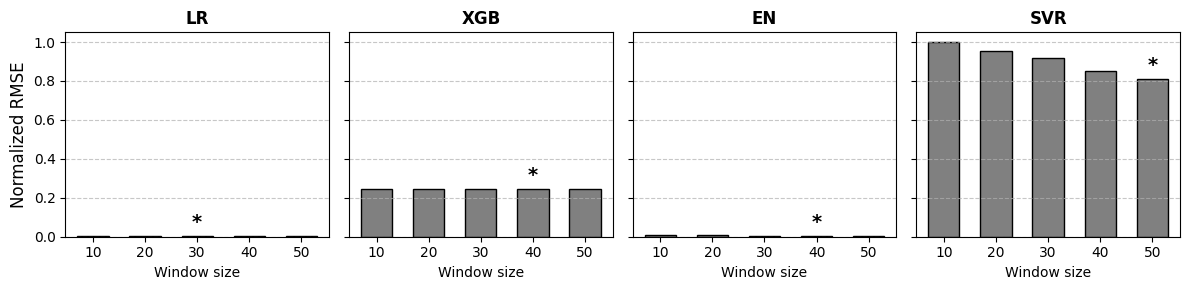

In [9]:
# -------------------------------------------------
print("--- BẢNG KẾT QUẢ RMSE GỐC (DỮ LIỆU THÔ) ---")
print("(Giá trị này là sai số thực tế tính bằng số lượng request)")
# Tạo bảng chéo Pivot cho RMSE gốc
pivot_rmse = results_df.pivot(index='Model', columns='k', values='RMSE')
print(pivot_rmse.round(2))
print("\n" + "="*50 + "\n")
# -------------------------------------------------

# Tìm Max RMSE để làm trần chuẩn hóa cho biểu đồ
max_rmse = results_df['RMSE'].max()
print(f"Giá trị kịch trần (Global Max_RMSE) tìm được: {max_rmse:.4f}\n")

# Tính NRMSE
results_df['NRMSE'] = results_df['RMSE'] / max_rmse

print("--- BẢNG KẾT QUẢ NORMALIZED RMSE (NRMSE) ---")
# Tạo bảng chéo Pivot cho NRMSE
pivot_nrmse = results_df.pivot(index='Model', columns='k', values='NRMSE')
print(pivot_nrmse.round(6))

# Cài đặt khung vẽ 1 hàng x 4 cột
fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
# fig.suptitle('Workload forecasting error for Increasing Workload', fontsize=14, fontweight='bold', y=1.05)

model_names = ['LR', 'XGB', 'EN', 'SVR']

for ax, model_name in zip(axes, model_names):
    # Lọc dữ liệu theo mô hình
    subset = results_df[results_df['Model'] == model_name]
    
    # Vẽ cột
    bars = ax.bar(subset['k'].astype(str), subset['NRMSE'], color='gray', edgecolor='black', width=0.6)
    
    # Trang trí
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Window size', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Tìm cột nhỏ nhất để đánh dấu *
    min_nrmse = subset['NRMSE'].min()
    for bar, val in zip(bars, subset['NRMSE']):
        if val == min_nrmse:
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, '*', ha='center', va='bottom', fontsize=14, fontweight='bold')

axes[0].set_ylabel('Normalized RMSE', fontsize=12)

plt.tight_layout()
# Lưu ảnh ra file
plt.savefig('NRMSE_increasing.png', dpi=300, bbox_inches='tight')
print("✅ Đã xuất biểu đồ ra file 'NRMSE_increasing.png'!")
plt.show()

In [10]:
# ---------------- PHẦN CODE CHỌN TỰ ĐỘNG ----------------
# Tìm index của dòng có RMSE nhỏ nhất
best_index = results_df['RMSE'].idxmin()

# Trích xuất thông tin của dòng đó
best_model_name = results_df.loc[best_index, 'Model']
best_k = results_df.loc[best_index, 'k']
best_rmse = results_df.loc[best_index, 'RMSE']
best_nrmse = results_df.loc[best_index, 'NRMSE']

print("\n" + "★"*50)
print(" KẾT QUẢ LỰA CHỌN TỐI ƯU TỰ ĐỘNG (BEST CHOICE)")
print("★"*50)
print(f"Thuật toán tốt nhất : {best_model_name}")
print(f"Window size (k)     : {best_k}")
print(f"RMSE                : {best_rmse:.4f}")
print(f"NRMSE               : {best_nrmse:.4f}")
print("★"*50 + "\n")


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 KẾT QUẢ LỰA CHỌN TỐI ƯU TỰ ĐỘNG (BEST CHOICE)
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
Thuật toán tốt nhất : LR
Window size (k)     : 30
RMSE                : 973.5174
NRMSE               : 0.0050
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

